In [3]:
from google.colab import files

uploaded = files.upload()

Saving cats_dogs.zip to cats_dogs.zip


In [4]:
import zipfile


with zipfile.ZipFile('/content/cats_dogs.zip', 'r') as zip_ref:
    zip_ref.extractall('cats_dogs')

print("Décompression terminée !")

Décompression terminée !


In [5]:
import os, math, re, random
from glob import glob
from pathlib import Path
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator


np.random.seed(42); tf.random.set_seed(42)

# Paths
DATA_ROOT = Path("/content/cats_dogs")
train_dir = (DATA_ROOT / "train" / "train") if (DATA_ROOT / "train" / "train").exists() else (DATA_ROOT / "train")
test_dir = (DATA_ROOT / "test" / "test") if (DATA_ROOT / "test" / "test").exists() else (DATA_ROOT / "test")

IMG_HEIGHT, IMG_WIDTH = 180, 180
batch_size = 32
seed = 1337

# Build DataFrames from folders
def build_df_from_folder(folder: Path, labeled : bool=True):
  exts = ('*.jpg', '*.jpeg', '*.png', '*.bmp')
  files = []
  for ex in exts:
    files.extend(glob(str(folder / '**' / ex), recursive=True))
  if not files:
    raise FileNotFoundError(f"No images found under {folder}")
  rows = []
  for f in files:
    if labeled:
      name = Path(f).name.lower()
      parent = Path(f).parent.name.lower()
      if parent in {"cat", "cats"}:
        label = "cat"
      elif parent in {"dog", "dogs"}:
        label = "dog"
      else:
        if re.search(r'(^|[^a-z])cat([^a-z]|$)', name): label = "cat"
        elif re.search(r'(^|[^a-z])dog([^a-z]|$)', name): label = "dog"
        else:
          continue
      rows.append({"filepath": f, "label": label})
    else:
      rows.append({"filepath": f})
  return pd.DataFrame(rows)

df_train_full = build_df_from_folder(train_dir, labeled=True)
df_test_full = build_df_from_folder(test_dir, labeled=False)

# Train validation split
from sklearn.model_selection import train_test_split
df_tr, df_val = train_test_split(
    df_train_full, test_size=0.2, stratify=df_train_full["label"], random_state=seed
    )

# Generators
train_gen = ImageDataGenerator (
    rescale=1./255,
    rotation_range=45,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.5,
    horizontal_flip=True,
)
val_gen = ImageDataGenerator(rescale=1./255)
test_gen = ImageDataGenerator(rescale=1./255)

train_flow = train_gen.flow_from_dataframe(
    df_tr,
    x_col="filepath",
    y_col="label",
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    class_mode="binary", batch_size=batch_size,
    shuffle=True, seed=seed, validate_filenames=False
)
val_flow = val_gen.flow_from_dataframe(
    df_val,
    x_col="filepath",
    y_col="label",
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    class_mode="binary", batch_size=batch_size,
    shuffle=False, seed=seed, validate_filenames=False
)
#Unlabeled  test for inference only
test_flow = test_gen.flow_from_dataframe(
    df_test_full,
    x_col="filepath",
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    class_mode=None, batch_size=batch_size,
    shuffle=False, seed=seed, validate_filenames=False
)

print({"train": train_flow.samples, "val": val_flow.samples, "test": test_flow.samples,
       "class_indices": train_flow.class_indices})

Found 20000 non-validated image filenames belonging to 2 classes.
Found 5000 non-validated image filenames belonging to 2 classes.
Found 12500 non-validated image filenames.
{'train': 20000, 'val': 5000, 'test': 12500, 'class_indices': {'cat': 0, 'dog': 1}}


### Analyse des images d'entraînement

Le jeu de données d'entraînement contient **20 000 images** pour la classe 'cat' (0) et **20 000 images** pour la classe 'dog' (1). Cela indique un ensemble de données bien équilibré entre les deux classes, ce qui est généralement favorable pour l'entraînement d'un modèle de classification car cela évite le biais d'une classe majoritaire.

Les sources potentielles de variabilité visuelle dans ces images incluent:
*   **Pose:** Les animaux peuvent être dans diverses positions (couchés, assis, debout, en mouvement), ce qui change leur apparence.
*   **Échelle:** La taille des animaux par rapport au cadre de l'image peut varier considérablement, certains étant proches et grands, d'autres éloignés et petits.
*   **Éclairage:** Les images peuvent être prises dans des conditions d'éclairage différentes (jour, nuit, intérieur, extérieur, ombres), affectant la couleur et la clarté.
*   **Arrière-plan:** Les arrière-plans sont très divers (maisons, parcs, rues, intérieurs), ce qui ajoute du "bruit" visuel que le modèle doit ignorer pour se concentrer sur l'animal.

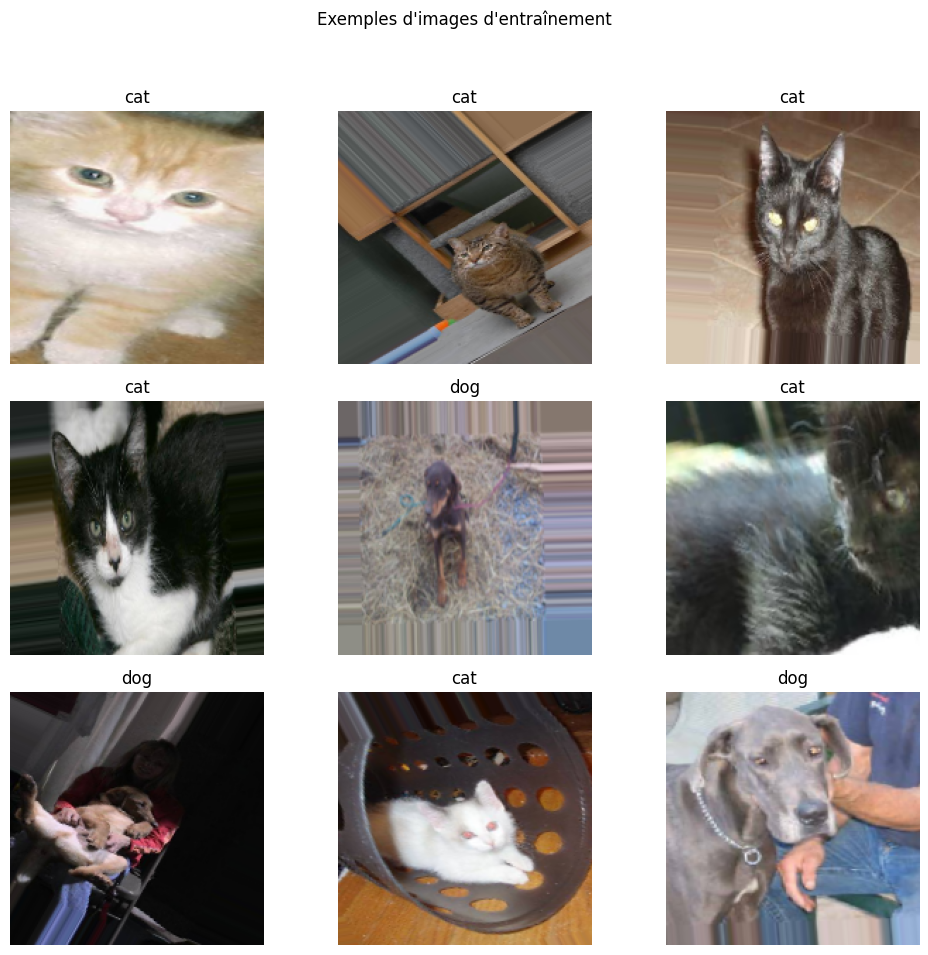

In [6]:
import matplotlib.pyplot as plt

# Get a batch of training images and labels
images, labels = next(train_flow)

# Reverse class_indices to map index back to class name
class_names = {v: k for k, v in train_flow.class_indices.items()}

plt.figure(figsize=(10, 10))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.title(class_names[labels[i]])
    plt.axis("off")
plt.suptitle("Exemples d'images d'entraînement")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Indices visuels pour la distinction Chat/Chien

Lors de l'examen des images de chats et de chiens, plusieurs indices visuels peuvent aider un modèle à les distinguer:

*   **Forme du visage et du museau:** Les chiens ont généralement un museau plus long et un visage plus anguleux, tandis que les chats ont un museau plus court et un visage plus rond.
*   **Oreilles:** Les oreilles des chiens sont très variées (droites, tombantes, coupées), mais les oreilles des chats sont souvent plus pointues et dressées, se terminant en triangle.
*   **Yeux:** Les yeux des chats sont souvent plus fendus et peuvent avoir des pupilles verticales dans certaines conditions de lumière, alors que les yeux des chiens sont généralement plus ronds avec des pupilles rondes.
*   **Taille et corpulence:** Bien qu'il y ait des exceptions, les chats sont généralement plus petits et plus gracieux, tandis que les chiens peuvent être très grands et plus musclés ou trapus.
*   **Comportement et posture:** La manière dont les animaux se tiennent ou interagissent avec leur environnement peut donner des indices (par exemple, la "queue en panache" des chats).
*   **Pelage et motifs:** Bien que très variés pour les deux espèces, certains motifs ou types de pelage peuvent être plus caractéristiques de l'un ou l'autre (par exemple, les rayures des tigres sur les chats vs. les taches des dalmatiens).

### Description de l'architecture du modèle CNN

Pour la classification des images de chats et de chiens, nous allons concevoir un réseau de neurones convolutif (CNN) qui combine des couches de convolution, de pooling, de dropout et des couches denses pour apprendre et distinguer les caractéristiques pertinentes. L'architecture prévue est la suivante :

1.  **Blocs convolutionnels :** Le modèle commencera par plusieurs blocs convolutionnels. Chaque bloc sera composé d'une couche `Conv2D` avec des filtres de taille 3x3 (une taille de filtre commune qui capture bien les motifs locaux sans augmenter excessivement la complexité), suivie d'une fonction d'activation ReLU. Nous augmenterons progressivement le nombre de filtres dans les couches successives (par exemple, 32, 64, 128) pour permettre au modèle d'apprendre des caractéristiques de plus en plus complexes et abstraites à partir des données d'entrée. Ces couches sont essentielles car elles détectent les motifs locaux tels que les bords, les textures et les coins, qui sont cruciaux pour distinguer les animaux.

2.  **Placement de MaxPooling :** Après chaque bloc convolutionnel (ou tous les deux blocs), nous ajouterons une couche `MaxPooling2D` de taille 2x2. Ces couches sont utilisées pour réduire les dimensions spatiales de la carte de caractéristiques, ce qui diminue le nombre de paramètres et la quantité de calculs dans le réseau. Cela permet également au modèle d'être plus robuste aux petites translations et déformations dans les images d'entrée, contribuant ainsi à l'invariance translationnelle.

3.  **Utilisation du Dropout pour la régularisation :** Afin de prévenir le surapprentissage (overfitting), nous intégrerons des couches `Dropout` après certains blocs convolutionnels et avant les couches denses finales. Le dropout fonctionne en désactivant aléatoirement un pourcentage des neurones d'une couche pendant l'entraînement, forçant le réseau à apprendre des représentations plus robustes et à ne pas trop dépendre d'un sous-ensemble spécifique de caractéristiques.

4.  **Couches denses finales :** Après avoir aplati la sortie des dernières couches convolutionnelles et de pooling, nous ajouterons une ou plusieurs couches `Dense` (couches entièrement connectées) pour effectuer la classification finale. La couche de sortie aura une seule unité avec une fonction d'activation sigmoïde. Étant donné que nous traitons un problème de classification binaire (chat ou chien), la fonction sigmoïde est le choix approprié car elle produit une sortie entre 0 et 1, que l'on peut interpréter comme la probabilité que l'image appartienne à la classe positive (par exemple, 'chien').

L'utilisation de l'entropie croisée binaire comme fonction de perte avec une sortie sigmoïde est fondamentale pour un tel problème de classification binaire, car elle mesure efficacement la différence entre la distribution de probabilité prédite par le modèle et la distribution réelle.

### Spécification et justification des hyperparamètres d'entraînement

Pour optimiser l'entraînement de notre modèle CNN, nous allons définir les hyperparamètres suivants :

1.  **Optimiseur : Adam**
    *   **Choix :** Nous utiliserons l'optimiseur Adam (Adaptive Moment Estimation).
    *   **Justification :** Adam est un algorithme d'optimisation populaire qui combine les avantages de l'AdaGrad et du RMSProp. Il calcule des taux d'apprentissage adaptatifs pour chaque paramètre du modèle, ce qui le rend efficace pour les problèmes d'apprentissage profond. Sa capacité à gérer des gradients clairsemés et des problèmes non stationnaires, ainsi que sa convergence rapide, en font un excellent choix par défaut pour une grande variété de tâches.

2.  **Taux d'apprentissage initial : 1e-4 (0.0001)**
    *   **Choix :** Un taux d'apprentissage initial de 0.0001 sera utilisé.
    *   **Justification :** Un taux d'apprentissage de 1e-4 est généralement considéré comme un bon point de départ pour les modèles de Deep Learning. Un taux trop élevé peut entraîner une divergence du modèle ou des oscillations autour du minimum, tandis qu'un taux trop faible peut rendre l'entraînement très lent. Ce taux permet un apprentissage stable sans risque de "sauter" le minimum optimal de la fonction de perte.

3.  **Taille du lot (Batch Size) : 32**
    *   **Choix :** La taille du lot sera de 32 images.
    *   **Justification :** La taille du lot de 32 a déjà été définie lors de la création des `ImageDataGenerator`. Elle représente un bon compromis entre la stabilité du gradient et l'efficacité de la mémoire. Des lots plus petits introduisent plus de bruit dans les mises à jour des gradients, ce qui peut aider à échapper aux minima locaux, mais ils sont moins efficaces en termes de calcul et peuvent nécessiter plus d'itérations pour converger. Des lots plus grands peuvent converger plus rapidement par époque mais nécessitent plus de mémoire et peuvent se retrouver coincés dans des minima locaux. Une taille de 32 est également une valeur couramment utilisée et optimisée pour l'utilisation des GPU/CPU.

4.  **Arrêt précoce (Early Stopping) et réduction du taux d'apprentissage sur plateau**
    *   **Choix :** Nous utiliserons l'arrêt précoce basé sur la perte de validation et une réduction du taux d'apprentissage si la performance stagne sur le jeu de validation.
    *   **Justification :**
        *   **Arrêt précoce :** Cette technique est cruciale pour prévenir le surapprentissage. Le modèle arrêtera l'entraînement si la perte sur l'ensemble de validation n'améliore pas pendant un certain nombre d'époques (patience). Cela garantit que le modèle ne continue pas à apprendre des spécificités du jeu d'entraînement qui ne généraliseraient pas bien à de nouvelles données.
        *   **Réduction du taux d'apprentissage sur plateau :** En complément, si la perte de validation ne s'améliore pas après quelques époques (mais avant l'arrêt précoce), le taux d'apprentissage sera réduit. Cela permet au modèle de sortir des plateaux ou de se rapprocher d'un minimum local en explorant l'espace des paramètres avec des pas plus petits, augmentant ainsi les chances d'une meilleure convergence.

In [7]:
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

model = models.Sequential([
    # Premier bloc convolutionnel
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25), # Ajout de dropout pour la régularisation

    # Deuxième bloc convolutionnel
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Troisième bloc convolutionnel
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Couches denses (Fully Connected)
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5), # Dropout supplémentaire pour les couches denses
    layers.Dense(1, activation='sigmoid') # Couche de sortie pour classification binaire
])

# Compile le modèle
model.compile(
    optimizer=Adam(learning_rate=0.0001), # Utilisation de l'optimiseur Adam avec le taux d'apprentissage spécifié
    loss='binary_crossentropy', # Entropie croisée binaire pour la classification binaire
    metrics=['accuracy'] # Métrique de précision pour évaluer la performance
)

# Afficher un résumé du modèle
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 51200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    26,214,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,308,673 (100.36 MB)

 Trainable params: 26,308,673 (100.36 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

epochs_fixed = 20 # Nombre fixe d'époques pour l'entraînement initial

print("Début de l'entraînement avec un nombre fixe d'époques...")
history_fixed = model.fit(
    train_flow,
    epochs=epochs_fixed,
    validation_data=val_flow,
    steps_per_epoch=train_flow.samples // batch_size,
    validation_steps=val_flow.samples // batch_size
)
print("Entraînement terminé.")

Début de l'entraînement avec un nombre fixe d'époques...
Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 1746s 3s/step - accuracy: 0.5583 - loss: 0.6788 - val_accuracy: 0.6288 - val_loss: 0.6354
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 1762s 3s/step - accuracy: 0.6431 - loss: 0.6248 - val_accuracy: 0.7091 - val_loss: 0.5723
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 1736s 3s/step - accuracy: 0.6738 - loss: 0.5966 - val_accuracy: 0.6480 - val_loss: 0.6229
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 1732s 3s/step - accuracy: 0.6881 - loss: 0.5804 - val_accuracy: 0.7023 - val_loss: 0.5542
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 1722s 3s/step - accuracy: 0.6993 - loss: 0.5686 - val_accuracy: 0.7133 - val_loss: 0.5506
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 1720s 3s/step - accuracy: 0.7092 - loss: 0.5564 - val_accuracy: 0.7416 - val_loss: 0.5240
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 1762s 3s/step - accuracy: 0.7150 - loss: 0.5481 - val_accuracy: 0.7582 - val_loss: 0.5005
Epoch 8/20
625/625 ━━━━━━━━━━━━━━

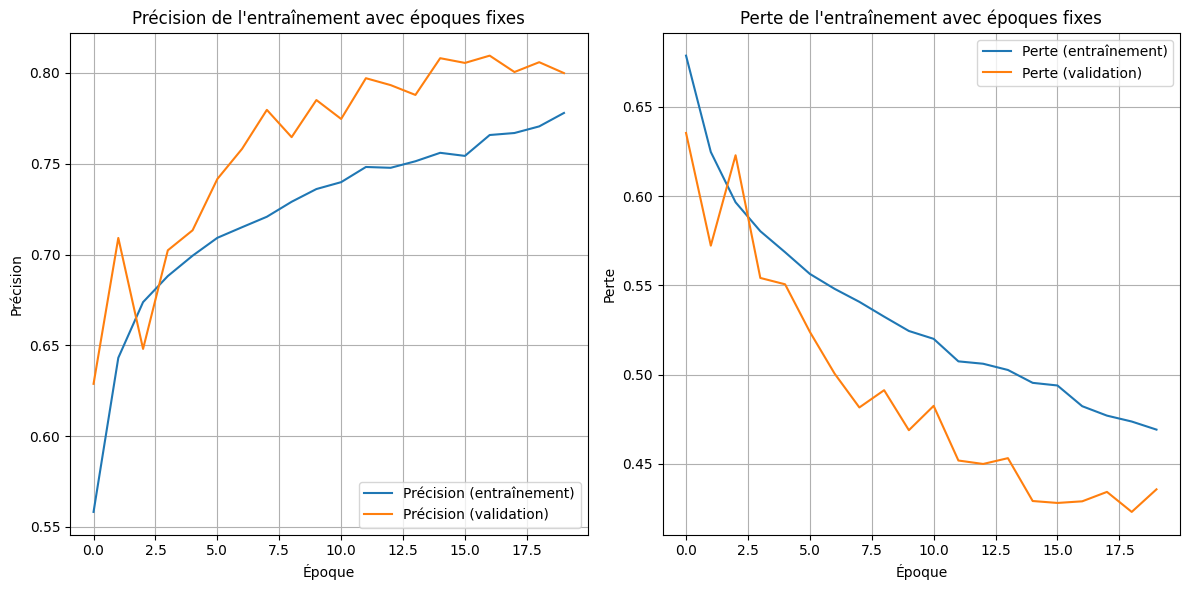

In [9]:
import matplotlib.pyplot as plt

def plot_training_history(history, title):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Précision (entraînement)')
    plt.plot(epochs_range, val_acc, label='Précision (validation)')
    plt.title(f'Précision de {title}')
    plt.xlabel('Époque')
    plt.ylabel('Précision')
    plt.legend(loc='lower right')
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Perte (entraînement)')
    plt.plot(epochs_range, val_loss, label='Perte (validation)')
    plt.title(f'Perte de {title}')
    plt.xlabel('Époque')
    plt.ylabel('Perte')
    plt.legend(loc='upper right')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Check if history_fixed is defined before plotting
if 'history_fixed' in locals():
    plot_training_history(history_fixed, "l'entraînement avec époques fixes")
else:
    print("La variable 'history_fixed' n'est pas définie. Veuillez vous assurer que la cellule d'entraînement précédente (cell_6f237731) a été exécutée avec succès avant d'exécuter cette cellule.")